# Portafolio Semana 9

## Gráficas de Ejercicios

Ejercicio 1:

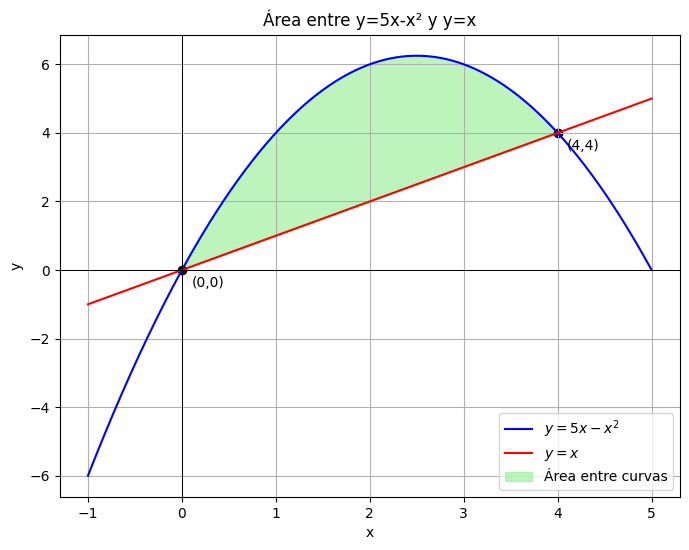

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.Symbol('x')

y1 = 5*x - x**2
y2 = x

# Convertimos a funciones numéricas para graficar
f1 = sp.lambdify(x, y1, 'numpy')
f2 = sp.lambdify(x, y2, 'numpy')

# Intervalo de graficación
X = np.linspace(-1, 5, 400)
Y1 = f1(X)
Y2 = f2(X)

# Creamos la gráfica
plt.figure(figsize=(8,6))
plt.plot(X, Y1, label=r"$y=5x-x^2$", color="blue")
plt.plot(X, Y2, label=r"$y=x$", color="red")

# Rellenamos el área entre las curvas en [0,4]
X_fill = np.linspace(0, 4, 400)
plt.fill_between(X_fill, f1(X_fill), f2(X_fill), color="lightgreen", alpha=0.6, label="Área entre curvas")

# Puntos de intersección
points = [(0,0),(4,4)]
for px,py in points:
    plt.scatter(px,py, color="black")
    plt.text(px+0.1, py-0.5, f"({px},{py})", fontsize=10)

# Ajustes de la gráfica
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.legend()
plt.title("Área entre y=5x-x² y y=x")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

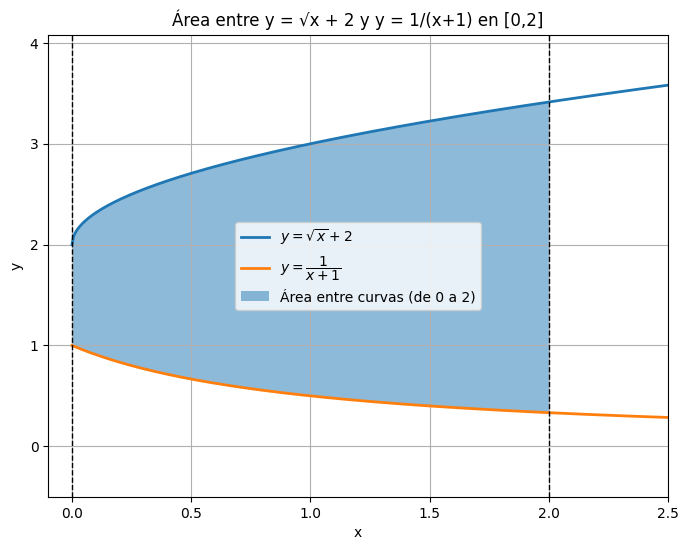

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir variable simbólica y funciones
x = sp.Symbol('x')
y1_sym = sp.sqrt(x) + 2        # función superior
y2_sym = 1/(x + 1)             # función inferior

# Convertir a funciones numéricas para numpy
y1 = sp.lambdify(x, y1_sym, 'numpy')
y2 = sp.lambdify(x, y2_sym, 'numpy')

# Rango para graficar (un poco más allá para contexto) y rango para rellenar área
X_plot = np.linspace(0, 2.5, 400)   # para mostrar un poco más que [0,2]
X_fill = np.linspace(0, 2, 400)     # intervalo donde se rellena el área

# Valores
Y1_plot = y1(X_plot)
Y2_plot = y2(X_plot)
Y1_fill = y1(X_fill)
Y2_fill = y2(X_fill)

# Crear la figura
plt.figure(figsize=(8,6))
plt.plot(X_plot, Y1_plot, label=r"$y=\sqrt{x}+2$", linewidth=2)
plt.plot(X_plot, Y2_plot, label=r"$y=\dfrac{1}{x+1}$", linewidth=2)

# Rellenar el área entre las curvas en [0,2]
plt.fill_between(X_fill, Y1_fill, Y2_fill, where=(Y1_fill>=Y2_fill), alpha=0.5,
                 label="Área entre curvas (de 0 a 2)")

# Líneas verticales x=0 y x=2
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(2, color='k', linestyle='--', linewidth=1)

# Ajustes y anotaciones
plt.xlim(-0.1, 2.5)
plt.ylim(min(np.min(Y2_plot), -0.5), np.max(Y1_plot) + 0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Área entre y = √x + 2 y y = 1/(x+1) en [0,2]")
plt.legend()
plt.grid(True)
plt.show()

Área simbólica: 2*sinh(1) + 10/3
Área (numérica) ≈ 5.683735720620936


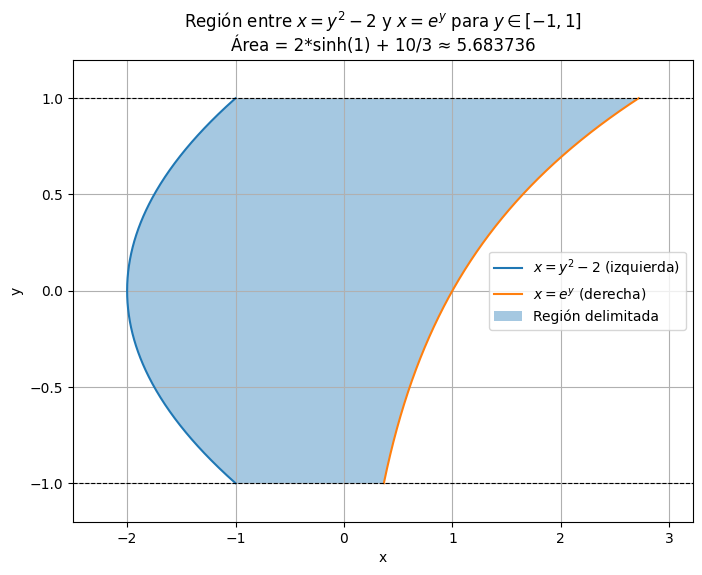

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- Símbolos y funciones simbólicas ---
y = sp.symbols('y')
x_left_sym = y**2 - 2       # x = y^2 - 2 (izquierda)
x_right_sym = sp.exp(y)     # x = e^y (derecha)

# Calcular el área simbólicamente
integrand_sym = x_right_sym - x_left_sym
area_sym = sp.integrate(integrand_sym, (y, -1, 1))
area_simpl = sp.simplify(area_sym)

print("Área simbólica:", area_simpl)
print("Área (numérica) ≈", float(area_simpl))

# --- Convertir a funciones numéricas para graficar ---
x_left = sp.lambdify(y, x_left_sym, 'numpy')
x_right = sp.lambdify(y, x_right_sym, 'numpy')

# Rango de y para graficar
Y = np.linspace(-1, 1, 500)
X_left = x_left(Y)
X_right = x_right(Y)

# Crear la figura
plt.figure(figsize=(8,6))

# Graficar las curvas como x = f(y) (ploteamos x en el eje horizontal y en el vertical)
plt.plot(X_left, Y, label=r"$x=y^2-2$ (izquierda)")
plt.plot(X_right, Y, label=r"$x=e^{y}$ (derecha)")

# Rellenar la región entre las curvas (usamos fill_betweenx porque x depende de y)
plt.fill_betweenx(Y, X_left, X_right, where=(X_right >= X_left),
                  alpha=0.4, label="Región delimitada")

# Dibujar las líneas horizontales y = -1 y y = 1 que delimitan verticalmente
plt.axhline(-1, color='k', linestyle='--', linewidth=0.8)
plt.axhline(1, color='k', linestyle='--', linewidth=0.8)

# Ajustes de la gráfica
plt.xlabel("x")
plt.ylabel("y")
plt.title("Región entre $x=y^2-2$ y $x=e^y$ para $y\\in[-1,1]$\nÁrea = {} ≈ {:.6f}".format(area_simpl, float(area_simpl)))
plt.legend()
# Ajustar límites x automaticamente con un margen
x_min = min(X_left.min(), X_right.min()) - 0.5
x_max = max(X_left.max(), X_right.max()) + 0.5
plt.xlim(x_min, x_max)
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.gca().set_aspect('auto')
plt.show()